### Дерево решений - регрессор

**Дерево регрессии** - это алгоритм машинного обучения, который строит иерархическую структуру вопросов о признаках данных, где каждый вопрос разделяет данные на ветви, а конечные узлы содержат ответы - предсказанные числовые значения.

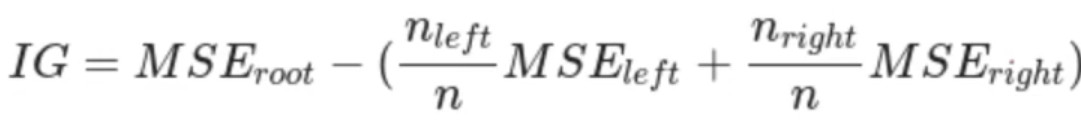

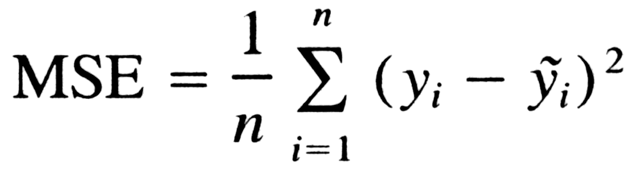

## Используемые библиотеки

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

## Используемый датасет

Размер матрицы признаков: (20640, 8)
Количество примеров: 20640
Количество признаков: 8
Названия признаков: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Целевая переменная: MedHouseVal



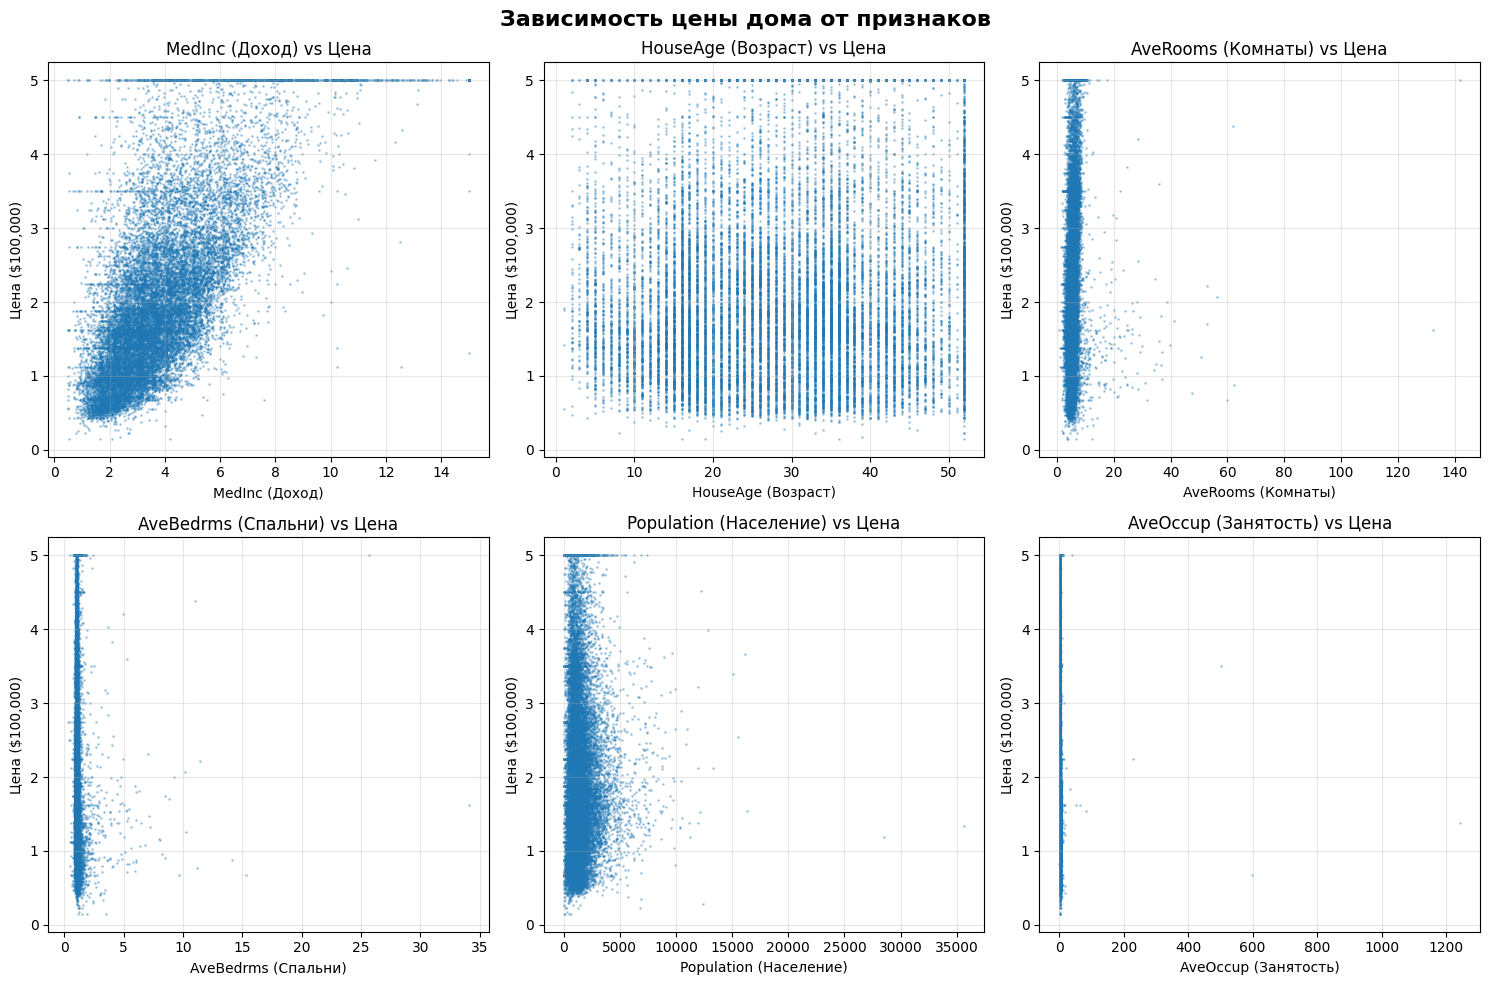

In [4]:
housing = fetch_california_housing()
X, y = housing.data, housing.target

print(f"Размер матрицы признаков: {X.shape}")
print(f"Количество примеров: {len(X)}")
print(f"Количество признаков: {X.shape[1]}")
print(f"Названия признаков: {housing.feature_names}")
print(f"Целевая переменная: {housing.target_names[0]}")
print()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

feature_names = ['MedInc (Доход)', 'HouseAge (Возраст)', 'AveRooms (Комнаты)',
                 'AveBedrms (Спальни)', 'Population (Население)', 'AveOccup (Занятость)']

for i in range(6):
    axes[i].scatter(X[:, i], y, alpha=0.3, s=1)
    axes[i].set_xlabel(feature_names[i])
    axes[i].set_ylabel('Цена ($100,000)')
    axes[i].set_title(f'{feature_names[i]} vs Цена')
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Зависимость цены дома от признаков", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print()

## Тепловая карта

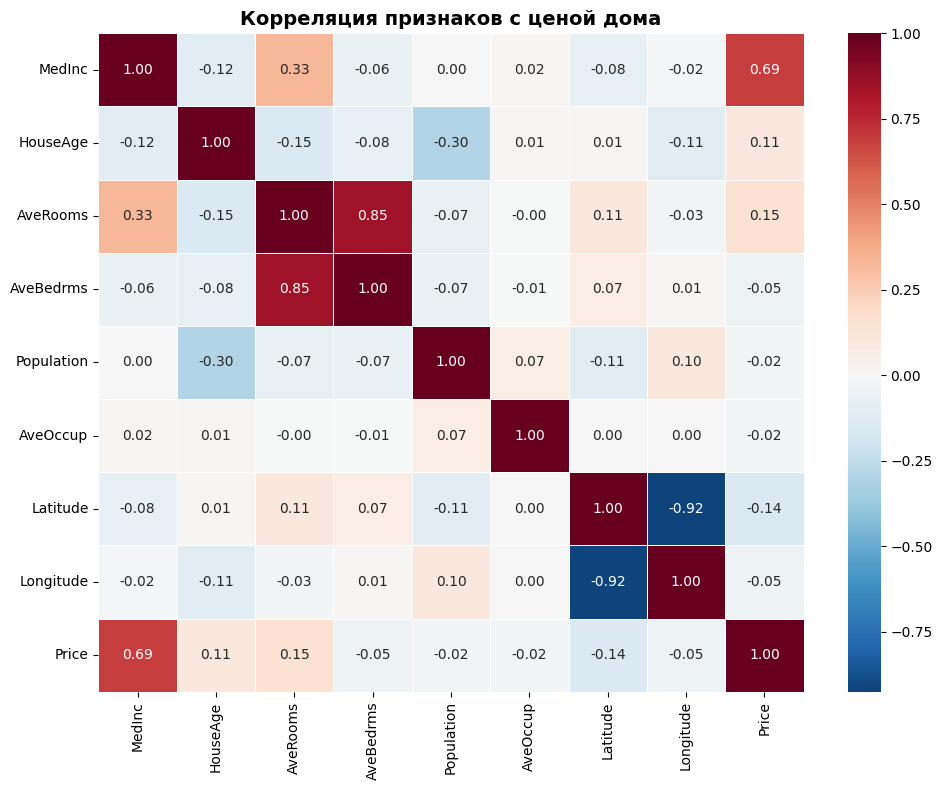

In [9]:
plt.figure(figsize=(10, 8))

df = pd.DataFrame(X, columns=housing.feature_names)
df['Price'] = y

correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5)

plt.title("Корреляция признаков с ценой дома", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print()

## Обработка датасета

Размер обучающей выборки: 16512 примеров
Размер тестовой выборки: 4128 примеров



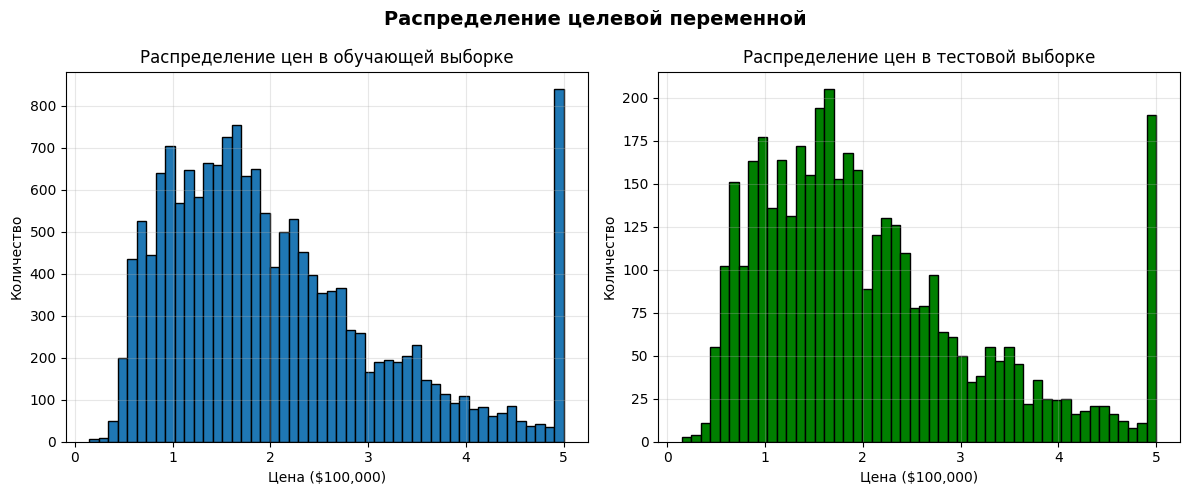

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Размер обучающей выборки: {X_train.shape[0]} примеров")
print(f"Размер тестовой выборки: {X_test.shape[0]} примеров")
print()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(y_train, bins=50, edgecolor='black')
plt.title('Распределение цен в обучающей выборке')
plt.xlabel('Цена ($100,000)')
plt.ylabel('Количество')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(y_test, bins=50, color='green', edgecolor='black')
plt.title('Распределение цен в тестовой выборке')
plt.xlabel('Цена ($100,000)')
plt.ylabel('Количество')
plt.grid(alpha=0.3)

plt.suptitle("Распределение целевой переменной", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print()


## Обучение модели

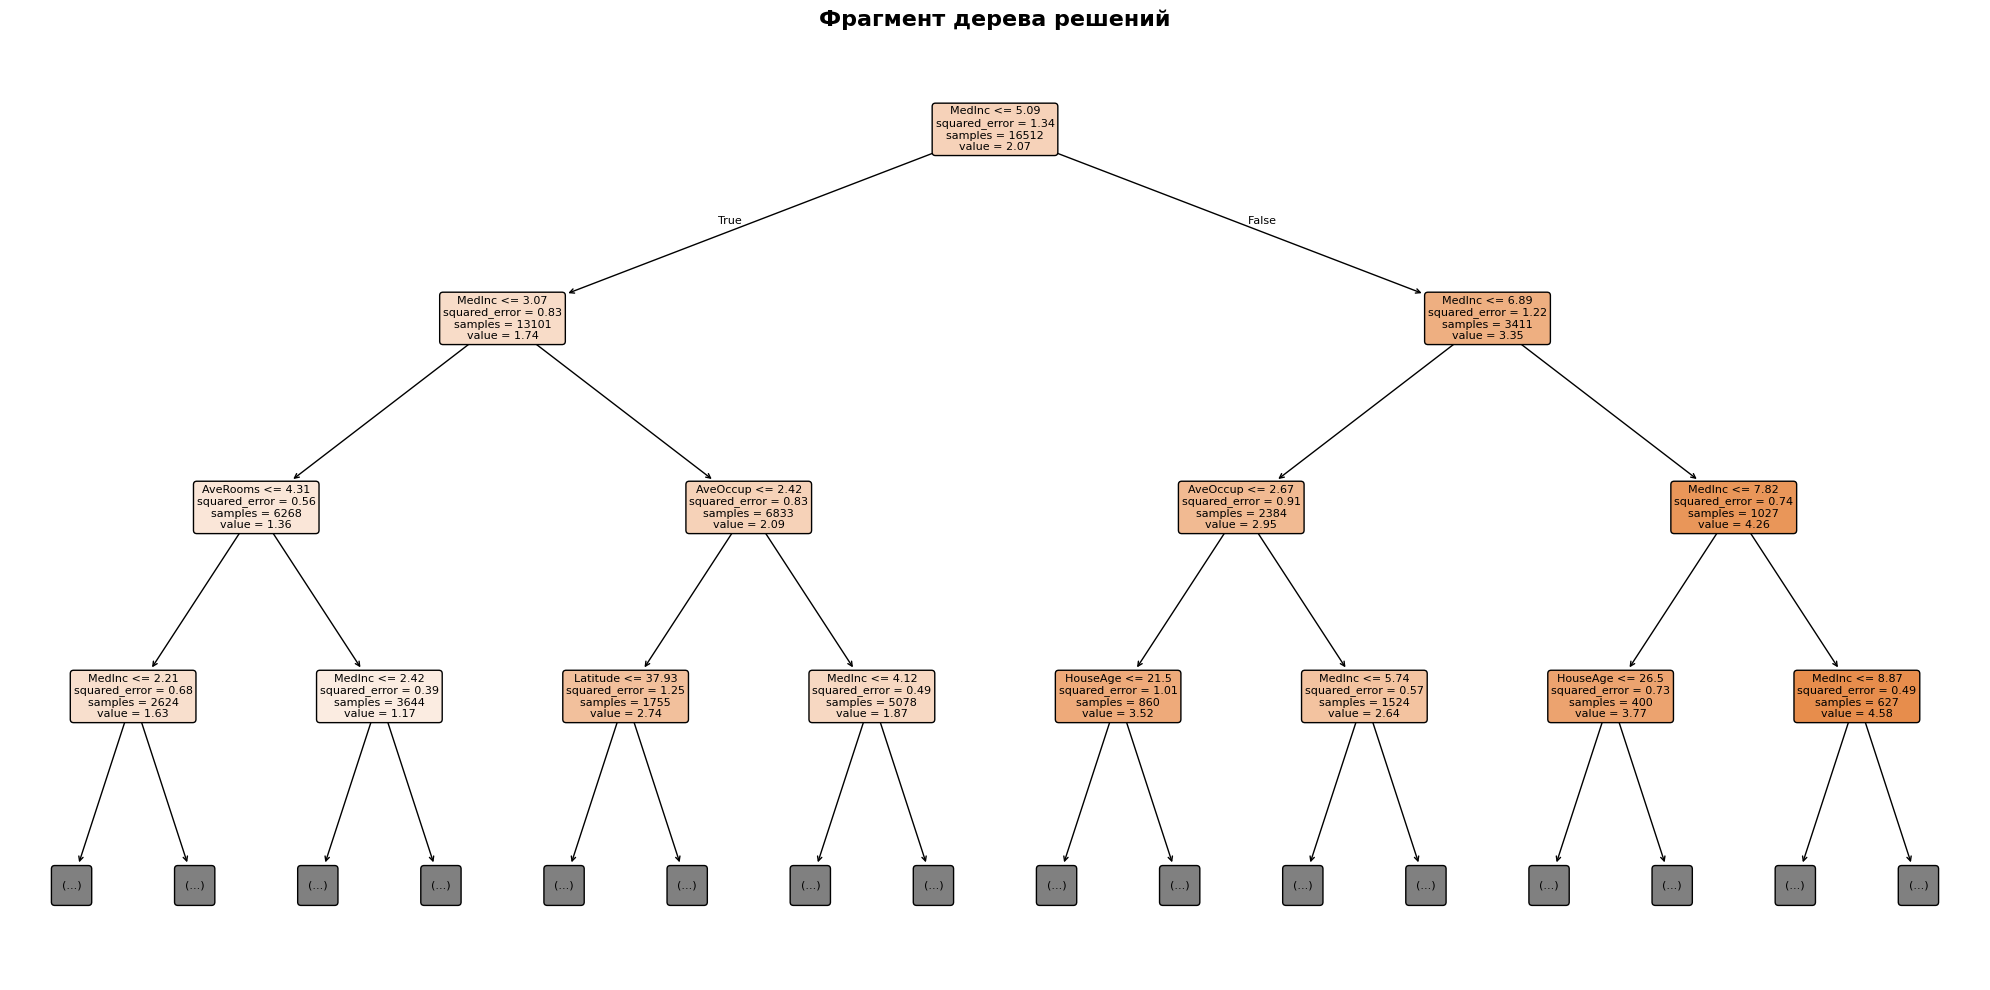

In [13]:
dt_regressor = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf_regressor = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

dt_regressor.fit(X_train, y_train)
rf_regressor.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(dt_regressor,
          max_depth=3,
          feature_names=housing.feature_names,
          filled=True,
          rounded=True,
          fontsize=8,
          precision=2)
plt.title("Фрагмент дерева решений", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print()

## Прогнозы модели

МЕТРИКИ КАЧЕСТВА МОДЕЛЕЙ
Дерево MSE                0.4076
Random Forest MSE         0.2947
Дерево MAE                0.4314
Random Forest MAE         0.3642



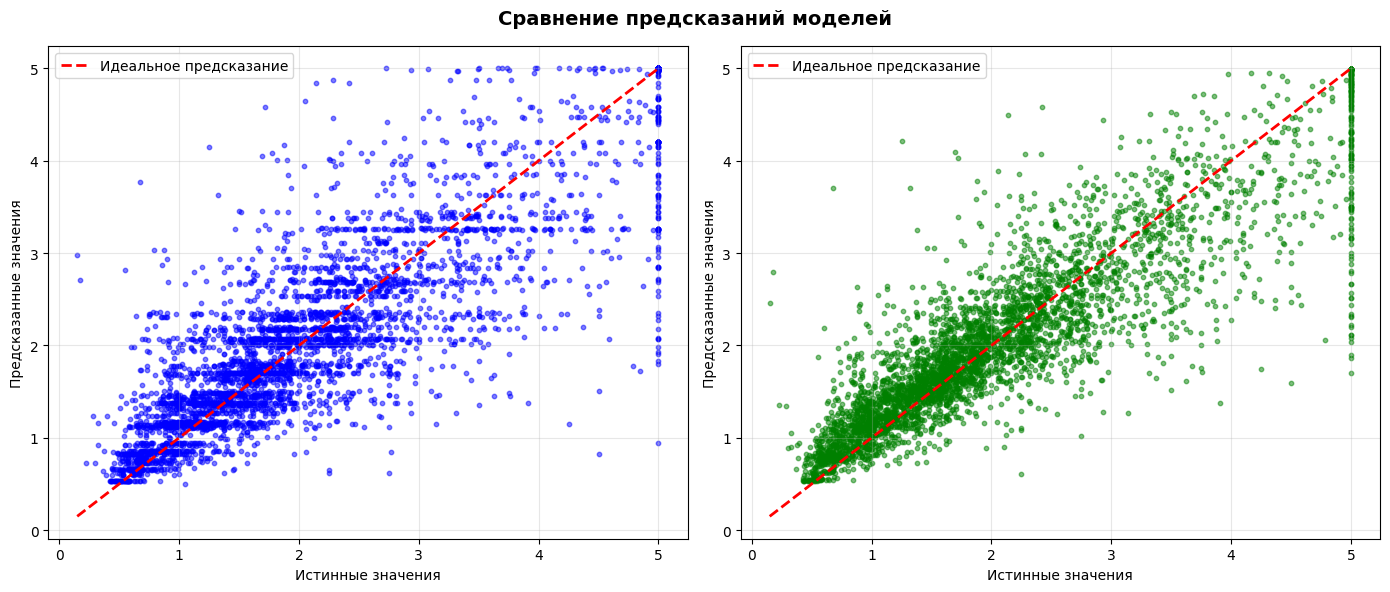

In [24]:
dt_predictions = dt_regressor.predict(X_test)
rf_predictions = rf_regressor.predict(X_test)

dt_mse = mean_squared_error(y_test, dt_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)

dt_mae = mean_absolute_error(y_test, dt_predictions)
rf_mae = mean_absolute_error(y_test, rf_predictions)

print("МЕТРИКИ КАЧЕСТВА МОДЕЛЕЙ")
print(f"{'Дерево MSE':<25} {dt_mse:.4f}")
print(f"{'Random Forest MSE':<25} {rf_mse:.4f}")
print(f"{'Дерево MAE':<25} {dt_mae:.4f}")
print(f"{'Random Forest MAE':<25} {rf_mae:.4f}")
print()


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, dt_predictions, alpha=0.5, c='blue', s=10)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Идеальное предсказание')
axes[0].set_xlabel('Истинные значения')
axes[0].set_ylabel('Предсказанные значения')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test, rf_predictions, alpha=0.5, c='green', s=10)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Идеальное предсказание')
axes[1].set_xlabel('Истинные значения')
axes[1].set_ylabel('Предсказанные значения')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Сравнение предсказаний моделей", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print()